In [22]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML
import matplotlib.animation as animation

np.random.seed(42)

In [23]:
def circle_map(theta, Omega, K):
    return (theta + Omega - (K/(2*np.pi)) * np.sin(2*np.pi*theta)) % 1

In [17]:
def simulate_cml(N, T, Omega, epsilon, K=1.0):
    theta = np.random.rand(N)
    history = np.zeros((T, N))
    
    for t in range(T):
        history[t] = theta
        
        new_theta = np.zeros(N)
        
        for i in range(N):
            left = theta[(i - 1) % N]
            right = theta[(i + 1) % N]
            
            new_theta[i] = (
                (1 - epsilon) * circle_map(theta[i], Omega, K) +
                (epsilon / 2) * (
                    circle_map(left, Omega, K) +
                    circle_map(right, Omega, K)
                )
            ) % 1
        
        theta = new_theta
    
    return history

In [13]:
N = 100
T = 300
Omega = 0.4
epsilon = 0.3

history = simulate_cml(N, T, Omega, epsilon)

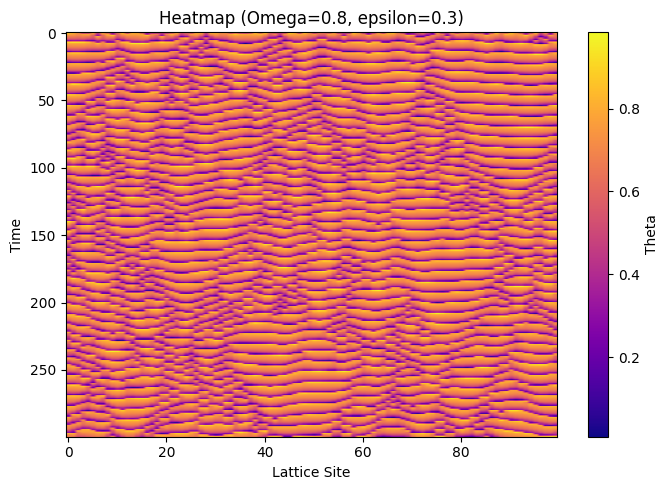

In [26]:
plt.figure(figsize=(7,5))
plt.imshow(history, aspect='auto', cmap='plasma')
plt.xlabel("Lattice Site")
plt.ylabel("Time")
plt.title(f"Heatmap (Omega={Omega}, epsilon={epsilon})")
plt.colorbar(label="Theta")
plt.tight_layout()
plt.show()

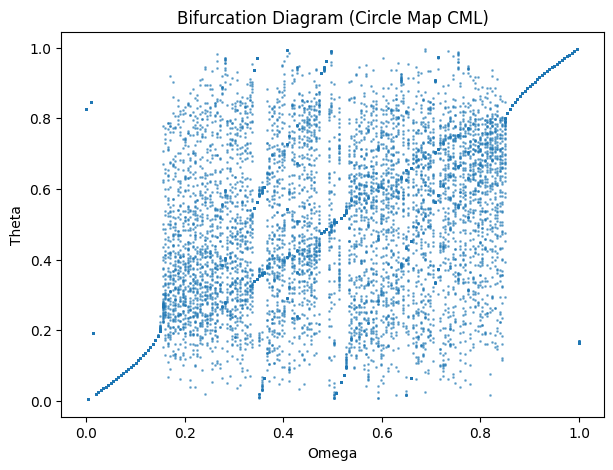

In [31]:
Omega_values = np.linspace(0, 1, 200)
epsilon = 0.3

Omega_list = []
theta_list = []

for Omega in Omega_values:
    theta = np.random.rand(N)
    
    for _ in range(200):
        new_theta = np.zeros(N)
        for i in range(N):
            left = theta[(i-1)%N]
            right = theta[(i+1)%N]
            
            new_theta[i] = (
                (1-epsilon)*circle_map(theta[i], Omega, 1) +
                (epsilon/2)*(circle_map(left, Omega, 1) +
                             circle_map(right, Omega, 1))
            ) % 1
        theta = new_theta
    
    for _ in range(50):
        new_theta = np.zeros(N)
        for i in range(N):
            left = theta[(i-1)%N]
            right = theta[(i+1)%N]
            
            new_theta[i] = (
                (1-epsilon)*circle_map(theta[i], Omega, 1) +
                (epsilon/2)*(circle_map(left, Omega, 1) +
                             circle_map(right, Omega, 1))
            ) % 1
        theta = new_theta
        
        Omega_list.append(Omega)
        theta_list.append(theta[0])

plt.figure(figsize=(7,5))
plt.scatter(Omega_list, theta_list, s=1, alpha=0.5)
plt.xlabel("Omega")
plt.ylabel("Theta")
plt.title("Bifurcation Diagram (Circle Map CML)")
plt.show()

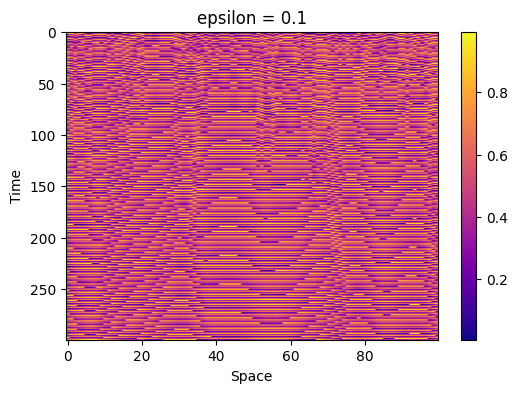

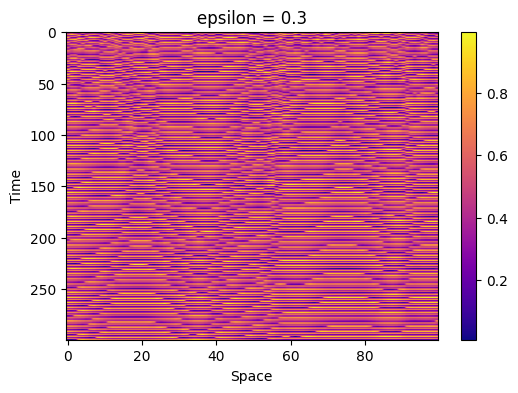

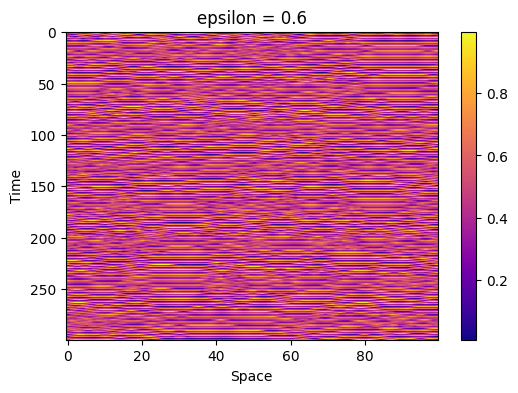

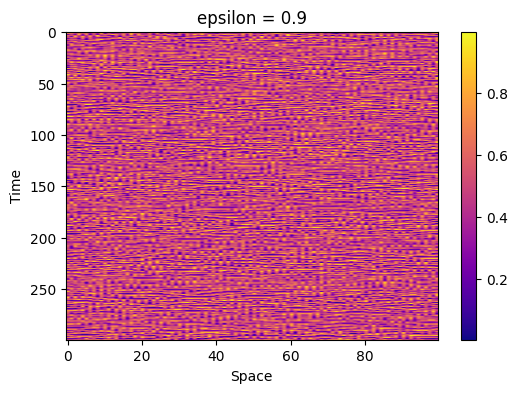

In [19]:
eps_values = [0.1, 0.3, 0.6, 0.9]
Omega = 0.4

for eps in eps_values:
    hist = simulate_cml(N, T, Omega, eps)
    
    plt.figure(figsize=(6,4))
    plt.imshow(hist, aspect='auto', cmap='plasma')
    plt.title(f"epsilon = {eps}")
    plt.xlabel("Space")
    plt.ylabel("Time")
    plt.colorbar()
    plt.show()

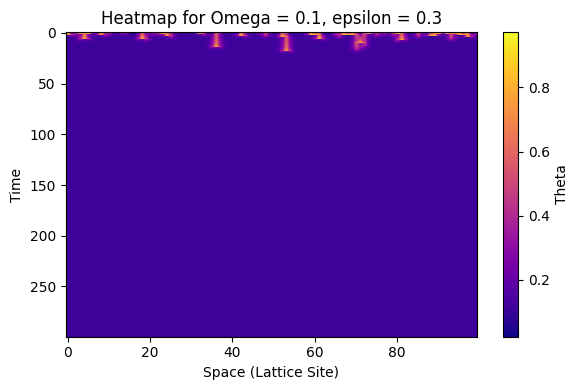

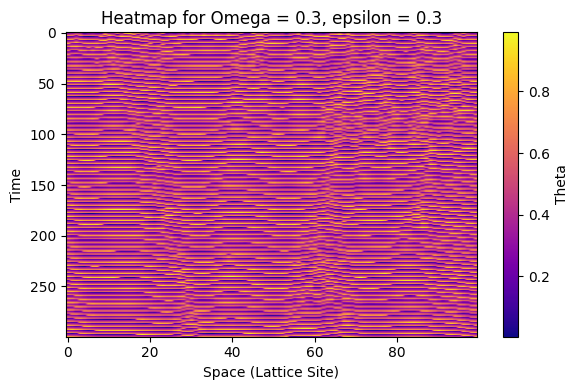

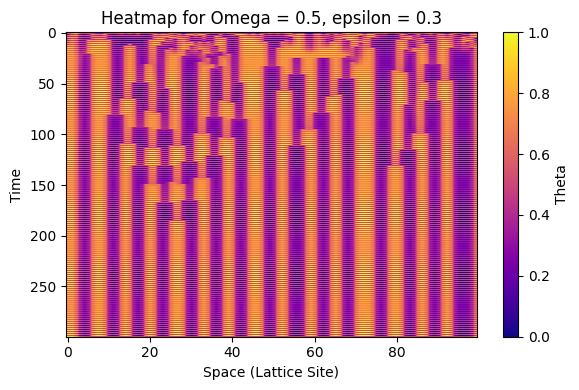

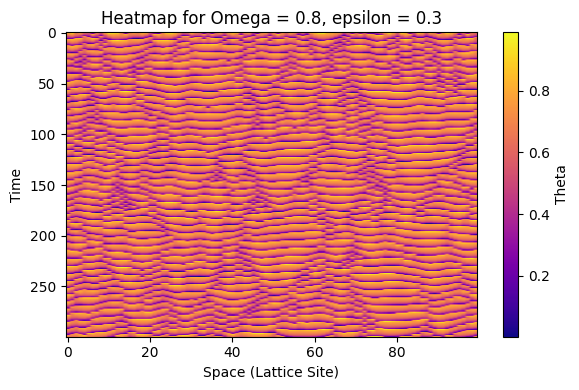

In [30]:
Omega_values = [0.1, 0.3, 0.5, 0.8]   
epsilon = 0.3                         

N = 100
T = 300

for Omega in Omega_values:
    history = simulate_cml(N, T, Omega, epsilon)
    
    plt.figure(figsize=(6,4))
    plt.imshow(history, aspect='auto', cmap='plasma')
    plt.title(f"Heatmap for Omega = {Omega}, epsilon = {epsilon}")
    plt.xlabel("Space (Lattice Site)")
    plt.ylabel("Time")
    plt.colorbar(label="Theta")
    plt.tight_layout()
    plt.show()

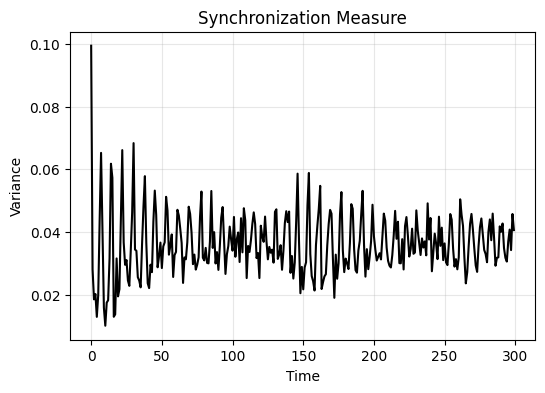

In [29]:
# Synchronization (Variance)
variance = np.var(history, axis=1)

plt.figure(figsize=(6,4))
plt.plot(variance, color='black')
plt.xlabel("Time")
plt.ylabel("Variance")
plt.title("Synchronization Measure")
plt.grid(alpha=0.3)
plt.show()

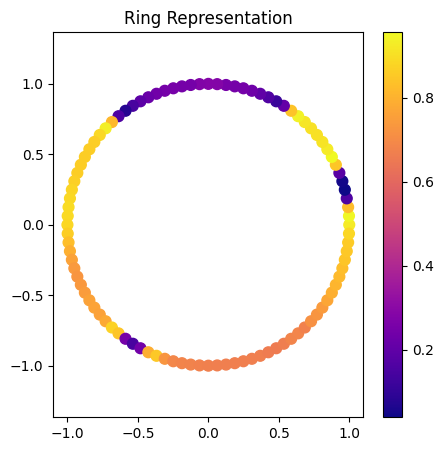

In [9]:
# Ring Visualization
def plot_ring(state):
    theta = np.linspace(0, 2*np.pi, len(state), endpoint=False)
    
    x = np.cos(theta)
    y = np.sin(theta)
    
    plt.figure(figsize=(5,5))
    plt.scatter(x, y, c=state, cmap='plasma', s=60)
    plt.colorbar()
    plt.axis('equal')
    plt.title("Ring Representation")
    plt.show()

plot_ring(history[-1])